In [1]:
import sys
print(sys.executable)

import libra_py
print("Libra loaded successfully")

/home/qingxin/miniconda3/envs/libra/bin/python
Libra loaded successfully


In [2]:
import os, glob, time, warnings
import h5py
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import LogLocator, NullFormatter
import multiprocessing as mp

from liblibra_core import *
from libra_py import units, data_stat, influence_spectrum, data_conv
from libra_py.workflows.nbra import step3
import libra_py.packages.cp2k.methods as CP2K_methods
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.workflows.nbra.decoherence_times as decoherence_times
import util.libutil as comn

from IPython.display import clear_output
%matplotlib inline

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

## Active-Space Selection

> **Goal:** Select the frontier occupied orbitals and low-lying virtual orbitals that are most relevant to the electronic excitations.

Based on the **Kohn–Sham orbital-energy distribution**, a reasonable active space was selected to include the frontier occupied orbitals and the low-lying unoccupied orbitals that contribute most significantly to the excitation dynamics.

### Orbital range

- **Active-space orbitals:** `18–46`
- **HOMO:** orbital `38`
- **LUMO:** orbital `39`
- **Selected occupied orbitals:** `18–38`
- **Selected virtual orbitals:** `39–46`

$$
\boxed{\text{Occupied: } 18\text{--}38 \qquad \text{Virtual: } 39\text{--}46}
$$

This active space captures the dominant **occupied-to-virtual transitions** while excluding deeper occupied orbitals and higher-energy virtual orbitals that are energetically remote from the excitation window of interest.

Shape of energies array: (3005, 36)
blue: 18
red: 17
cyan: 1


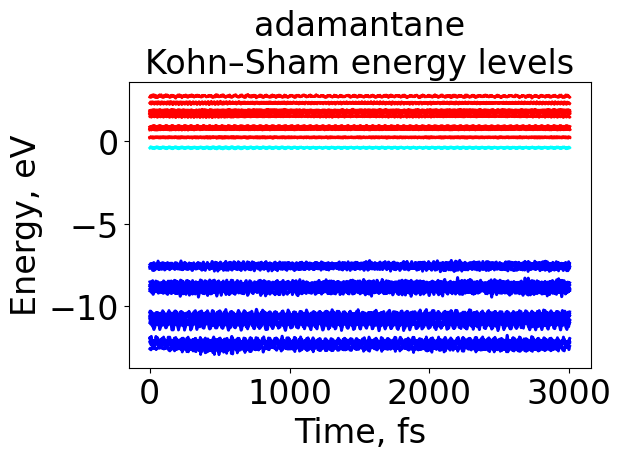

In [11]:
%matplotlib inline

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(3.21 * 2, 2.41 * 2))

energies = []

for step in range(5900, 8905):
    try:
        energy = np.diag(
            sp.load_npz(
                f'../step2_B3LYP/new_res/E_ks_{step}.npz'
            ).toarray()
        )
        energy_shape = energy.shape[0] // 2
        energies.append(energy[:energy_shape])

    except Exception as error:
        print(f"Error loading E_ks_{step}.npz: {error}")

if not energies:
    raise RuntimeError("No energy files were loaded.")

energies = np.asarray(energies) * units.au2ev
print(f"Shape of energies array: {energies.shape}")

color_counter = {
    'blue': 0,
    'red': 0,
    'cyan': 0,
    'gray': 0
}

for orbital in range(energies.shape[1]):

    if orbital == 18:
        color = 'cyan'
    elif 0 <= orbital < 18:
        color = 'blue'
    elif 19 <= orbital < 38:
        color = 'red'
    else:
        color = 'gray'

    color_counter[color] += 1

    ax.plot(
        energies[:, orbital],
        color=color,
        linewidth=2
    )

ax.set_xlabel('Time, fs')
ax.set_ylabel('Energy, eV')
ax.set_title('adamantane\nKohn–Sham energy levels')

for color, count in color_counter.items():
    if color != 'gray':
        print(f'{color}: {count}')

fig.tight_layout()

fig.savefig(
    'ks_0_methy.png',
    dpi=600,
    facecolor='white',
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

## Step 3: Data Generation

The Step 3 data were generated from the Step 2 outputs using the selected active space of orbitals `18–46`, where orbital `38` is the HOMO and orbital `39` is the LUMO.

In [3]:
params_active_space = {
    'lowest_orbital': 38-18, 'highest_orbital': 38+18, 'num_occ_orbitals': 18, 'num_unocc_orbitals': 18,
    'path_to_npz_files': os.getcwd()+'/../step2_B3LYP/res', 
    'logfile_directory': os.getcwd()+'/../step2_B3LYP/all_logfiles',
    'path_to_save_npz_files': os.getcwd()+'/../step2_B3LYP/new_res'
}
new_lowest_orbital, new_highest_orbital = step3.limit_active_space(params_active_space)

mkdir: cannot create directory ‘/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step3/../step2_B3LYP/new_res’: File exists


Restricting the active space for S..
Restricting the active space for St..
Restricting the active space for E..
Done with limiting the active space
Your new path_to_npz_files is now: /vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step3/../step2_B3LYP/new_res
Use the new lowest_orbital: 21 and highest_orbital: 56


In [4]:
pwd

'/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step3'

In [5]:
 os.getcwd()+'../step2_B3LYP/all_logfiles'

'/vscratch/grp-alexeyak/qingxin/devel3_300K_11_23/step3../step2_B3LYP/all_logfiles'

In [6]:
params_mb_sd = {
          'lowest_orbital': new_lowest_orbital, 'highest_orbital': new_highest_orbital, 'num_occ_states': 18, 'num_unocc_states': 18,
          'isUKS': 0, 'number_of_states': 30, 'tolerance': 0.0, 'verbosity': 0, 'use_multiprocessing': True, 'nprocs': 12,
          'is_many_body': True, 'time_step': 1.0, 'es_software': 'cp2k',
          'path_to_npz_files': params_active_space['path_to_save_npz_files'],
           'logfile_directory': os.getcwd()+'/../step2_B3LYP/all_logfiles',
          'path_to_save_sd_Hvibs': os.getcwd()+'/../step33three_B3LYP',
          'outdir': os.getcwd()+'/../step33three_B3LYP', 'start_time': 5900, 'finish_time': 8905, 'sorting_type': 'energy',
         }

step3.run_step3_sd_nacs_libint(params_mb_sd)
clear_output()

## Influence Spectrum

The influence spectrum was computed from the time-dependent energy gap between states `0` and `1`. The energy-gap trajectory was used to construct the autocorrelation function and the corresponding spectral density, $|J(\omega)|^2$, over the frequency range up to `4000 cm⁻¹`.

The contribution from low-frequency modes below `100 cm⁻¹` was quantified by integrating the spectrum in this region and comparing it with the total spectral intensity.

For additional details on the influence-spectrum analysis and its implementation, please refer to the [example analysis notebook](https://github.com/AkimovLab/Project_ML-BP/blob/main/4_analysis/pbe_plus_u/pristine/analysis.ipynb) and the JCP article, [*Excited-State Dynamics in Monolayer Black Phosphorus Revisited: Accounting for Many-Body Effects*](https://pubs-aip-org.gate.lib.buffalo.edu/aip/jcp/article/155/13/134106/1030258/Excited-state-dynamics-in-monolayer-black).


/tmp/ipykernel_222186/1629197941.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  low_integral = np.trapz(J2ij_np[low_mask], Wij_np[low_mask])
/tmp/ipykernel_222186/1629197941.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_integral = np.trapz(J2ij_np, Wij_np)


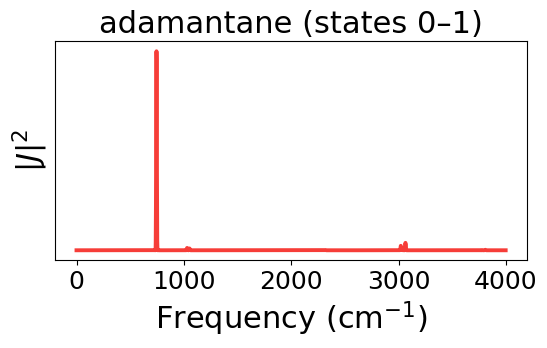

In [4]:
%matplotlib inline
# For computing influence spectra
params_inf_cpec = {
    "dt": 1.0,
    "wspan": 4000.0,
    "dw": 1.0,
    "do_output": False,
    "do_center": True,
    "acf_type": 1,
    "data_type": 0
}

# Selecting the two states
i = 0
j = 1


data_ij = []
for step in range(energies.shape[0]):
    x = MATRIX(1, 1)
    gap = abs(energies[step, j] - energies[step, i])  
    x.set(0, 0, gap)
    data_ij.append(x)


Tij, ACFij, uACFij, Wij, Jij, J2ij = influence_spectrum.recipe1(
    data_ij, params_inf_cpec
)


low_freq_cutoff = 100  # cm^-1

Wij_np = np.array(Wij)
J2ij_np = np.array(J2ij)

low_mask = Wij_np <= low_freq_cutoff
low_integral = np.trapz(J2ij_np[low_mask], Wij_np[low_mask])
total_integral = np.trapz(J2ij_np, Wij_np)
ratio = low_integral / total_integral

plt.figure(figsize=(6, 4))

plt.plot(
    Wij,
    J2ij,
    color="#F6322D",     
    linewidth=2.8,
    alpha=0.95
)

plt.xlabel('Frequency (cm$^{-1}$)', fontsize=22)
plt.ylabel(r'$|J|^2$', fontsize=22)
plt.yticks([])

plt.title(f'adamantane (states {i}–{j})', fontsize=22)
plt.tick_params(axis='both', labelsize=18)

plt.tight_layout()
plt.show()


## Time-Dependent Excitation Energies

The time-dependent configuration-interaction energies were extracted from the Step 3 vibronic Hamiltonian files and converted from atomic units to electronvolts using `units.au2ev`.

The excitation energy of each state was calculated relative to the ground state:

$$
\Delta E_i(t) = E_i(t) - E_0(t)
$$

The lowest 30 electronic states were plotted over the selected molecular-dynamics time interval. A blue-to-red color gradient was used to indicate increasing state index, allowing the temporal evolution and energetic distribution of the excited states to be visualized.

Checking file: /mnt/d/PCA_test/velocity/ad_paper/devel3_300K_11_23/step33three_B3LYP/Hvib_ci_5900_re.npz
Exists? True


/tmp/ipykernel_222186/1257499978.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("coolwarm", n_states_to_plot)   # low state blue → high state red


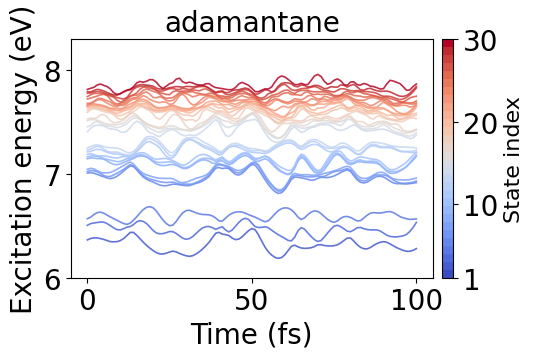

In [8]:
%matplotlib inline

params = {
    "path_to_energy_files": "/mnt/d/PCA_test/velocity/ad_paper/devel3_300K_11_23/step33three_B3LYP",
    "dt": 1.0,
    "prefix": "Hvib_ci_",   
    "suffix": "_re",
    "istep": 5900,
    "fstep": 6001
}


plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20
})

folder = params["path_to_energy_files"]


test_file = f"{folder}/Hvib_ci_{params['istep']}_re.npz"
print("Checking file:", test_file)
print("Exists?", os.path.exists(test_file))


md_time, energies = CP2K_methods.extract_energies_sparse(params)
energies = energies * units.au2ev


n_states_to_plot = min(30, energies.shape[1])

fig, ax = plt.subplots(figsize=(6, 4))

cmap   = cm.get_cmap("coolwarm", n_states_to_plot)   # low state blue → high state red
colors = [cmap(i / (n_states_to_plot - 1)) for i in range(n_states_to_plot)]

for i in range(n_states_to_plot):
    ax.plot(md_time,
            energies[:, i] - energies[:, 0],
            lw=1.2,
            color=colors[i],
            alpha=0.85)

# colorbar is state index
sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=1, vmax=n_states_to_plot))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("State index", fontsize=16)
cbar.set_ticks([1, 10, 20, 30])

ax.set_title("adamantane")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Excitation energy (eV)")
ax.set_ylim(6, 8.3)

fig.tight_layout()
fig.savefig("ci_energy_vs_time.png", dpi=300, bbox_inches="tight")

## Kohn–Sham Orbital-Energy Visualization

Based on the orbital-energy analysis described above, a short segment of the molecular-dynamics trajectory was selected for visualization. The Kohn–Sham orbital energies from steps `5900–5940` were extracted from the Step 2 output files.

Shape of energies array: (41, 36)


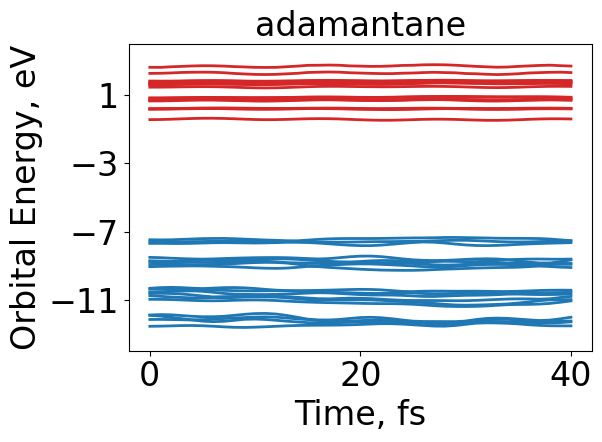

#1F77B4: 18
#D62728: 18


In [9]:
plt.rcParams.update({
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
})

plt.figure(figsize=(3.21*2, 2.41*2))

energies = []
for i in range(5900, 5941):
    try:
        energy = np.diag(
            sp.load_npz(f'../step2_B3LYP/new_res/E_ks_{i}.npz').toarray()
        )
        energy_shape = int(energy.shape[0] / 2)
        energies.append(energy[:energy_shape])
    except Exception as e:
        print(f"Error loading file E_ks_{i}.npz: {e}")

energies = np.array(energies) * units.au2ev
print(f"Shape of energies array: {energies.shape}")

color_counter = {
    '#1F77B4': 0,
    '#D62728': 0,
}

for i in range(energies.shape[1]):
    if 18 <= i <= 46:
        color = '#D62728'
        color_counter[color] += 1
    elif 0 <= i <= 17:
        color = '#1F77B4'
        color_counter[color] += 1
    else:
        color = 'gray'

    plt.plot(
        energies[:, i],
        color=color,
        linewidth=2,
        linestyle='-'
    )

plt.xlabel('Time, fs')
plt.ylabel('Orbital Energy, eV')
plt.title('adamantane')

plt.ylim(-14, 4)          
plt.yticks(np.arange(-11, 4, 4))    

plt.tick_params(axis='both', which='major')

plt.tight_layout()
plt.savefig('ks_0_methy111.png', dpi=600, facecolor='white')
plt.show()

for color, count in color_counter.items():
    print(f'{color}: {count}')

## Construction of the Vibronic Hamiltonian Files

Vibronic Hamiltonians were built with `CP2K_methods.cp2k_compute_adi` (Libra) for 3001 configurations spanning trajectory steps 5900–8900. Each step combines three inputs: the aligned nuclear geometry of the corresponding frame, used only to construct the Hamiltonian object; the excitation energies and CI coefficients of 30 states, parsed from the CP2K TD-DFT log with a CI threshold of 0.01; and the KS orbital overlap and time-overlap matrices (`S_ks_*.npz`, `St_ks_*.npz`), which transform the single-particle description into the many-body basis via determinants of the appropriate overlap submatrices. State phases and ordering were tracked along the trajectory. The resulting 30 × 30 adiabatic Hamiltonian, overlap, time-overlap, and vibronic Hamiltonian matrices were written to plain-text files (`ham_adi_*.txt`, `s_adi_*.txt`, `st_adi_*.txt`, `hvib_adi_*.txt`) using Δt = 1 fs. Further examples are given in [`6_dynamics/2_nbra_workflows/9_step4/tutorial.ipynb`](6_dynamics/2_nbra_workflows/9_step4/tutorial.ipynb).

In [3]:
params_tddft = {'number_of_states': 30, 
                'tolerance': 0.0, 
                'logfile_name': '../step2_B3LYP/all_logfiles/step_5900.log', 
                'isUKS': False, 
                }
info, data = CP2K_methods.read_cp2k_tddfpt_log_file(params_tddft)

In [5]:
print(info)

{'nocc': 38, 'nelec': 76, 'nao': 68, 'nmo': 68, 'nci': 30, 'min_occ': 31, 'max_occ': 38, 'min_vir': 39, 'max_vir': 70, 'nact': 68, 'actual_orbital_space': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]}


In [4]:
sample_matrix = sp.load_npz('../step2_B3LYP/res/St_ks_5902.npz')

In [6]:
sample_matrix.shape

(74, 74)

In [7]:
# Lowest and highest orbital, Here HOMO is 38
#params['lowest_orbital'] = 38-18
#params['highest_orbital'] = 38+18
# so:

56 - 20 + 1

37

In [8]:
lowest_orbital = 20
ndim = sample_matrix.shape[0] // 2
actual_orbital_space = list(range(lowest_orbital, lowest_orbital + ndim ))

print(actual_orbital_space)

[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56]


In [9]:
labels, q = CP2K_methods.read_trajectory_xyz_file("0_methyl_align.xyz", 0)
print(labels)
print(q)

params = {"atom_labels":labels, "timestep":0, 
          "dt":1.0*units.fs2au,
          "nelec_act_space":None,
          "ci_threshold":0.01,
          "lowest_orbital":20 ,          
          "nstates": 30,
          "is_first_time":{0:True},
          "act_state":{0:1},
         }
print(params)

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

res = "adamantane_results"
# Create working directory, if doesn't exist
if not os.path.exists(res):
    os.mkdir(res)

# Do the 3000 steps 
for i in range(3001):
    #print(F"======== Iteration {i} ==============")
    labels, q = CP2K_methods.read_trajectory_xyz_file("0_methyl_align.xyz", i)
    params["timestep"] = i
    params["logfile_name"] = F"../step2_B3LYP/all_logfiles/step_{5900+i}.log"
    params["time_overlap_filename"] = F"../step2_B3LYP/res/St_ks_{5900+i}.npz"
    params["overlap_filename"] = F"../step2_B3LYP/res/S_ks_{5900+i}.npz"
    
    obj = CP2K_methods.cp2k_compute_adi(q, params, full_id)        
    obj.ham_adi.show_matrix(F"{res}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{res}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{res}/st_adi_{i}.txt")
    obj.overlap_adi.real().show_matrix(F"{res}/s_adi_{i}.txt")

['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
{'atom_labels': ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H'], 'timestep': 0, 'dt': 41.339396444811904, 'nelec_act_space': None, 'ci_threshold': 0.01, 'lowest_orbital': 20, 'nstates': 30, 'is_first_time': {0: True}, 'act_state': {0: 1}}


/home/qingxin/libra/_build/src/libra_py/packages/cp2k/methods.py:2978: ComplexWarning: Casting complex values to real discards the imaginary part
  st_mo = st_mo.astype(np.float64, copy=False)
/home/qingxin/libra/_build/src/libra_py/citools/slatdet.py:397: ComplexWarning: Casting complex values to real discards the imaginary part
  S_AB[i, j] = np.linalg.det(S_a) * np.linalg.det(S_b) * ph_A[i] * ph_B[j]
/home/qingxin/libra/_build/src/libra_py/packages/cp2k/methods.py:3047: ComplexWarning: Casting complex values to real discards the imaginary part
  obj.time_overlap_adi.set(i, j, float(st_ci[i, j]))
/home/qingxin/libra/_build/src/libra_py/packages/cp2k/methods.py:3048: ComplexWarning: Casting complex values to real discards the imaginary part
  obj.overlap_adi.set(i,  j, float(s_ci[i,j]) )


In [10]:
def read_files_new(data_path, istep, fstep, dt, _nstates=None):
    """
    dt - in fs
    """
    
    nsteps = fstep - istep
    NSTEPS = nsteps
    print(F"Number of steps = {NSTEPS}")

    # ================= Reading the data ======================
    # Get the number of states:
    st = np.loadtxt(F"{data_path}/st_adi_{istep}.txt")
    NSTATES = st.shape[0]
    max_nstates = NSTATES
    if _nstates is not None:
        NSTATES = min(_nstates, NSTATES)
        
    rng = Py2Cpp_int(list(range(NSTATES)))

    print(F"NSTATES = {NSTATES}")
    

    #==== Read time-overlap, adiabatic Hamiltonians and vibronic Hamiltonians ==========
    St_adi, Ham_adi, Hvib_adi, NAC_adi, Basis_transform = [], [], [], [], []
    for i in range(istep,fstep):
    
        # Time-overlaps
        st = CMATRIX(max_nstates, max_nstates)
        st_red = CMATRIX(NSTATES, NSTATES)
        st.Load_Matrix_From_File(F"{data_path}/st_adi_{i}.txt")
        pop_submatrix(st, st_red, rng, rng)
        St_adi.append(st_red)
        
        # Adiabatic Hamiltonian
        ham_adi = CMATRIX(max_nstates, max_nstates)
        ham_adi_red = CMATRIX(NSTATES, NSTATES)
        ham_adi.Load_Matrix_From_File(F"{data_path}/ham_adi_{i}.txt")
        pop_submatrix(ham_adi, ham_adi_red, rng, rng)
        Ham_adi.append(ham_adi_red)

        # NACs
        #nac_adi =  (ham_adi - hvib_adi)*(0.0+1.0j)
        nac_adi_red = (st_red - st_red.H())/(2.0*dt * units.fs2au)
        NAC_adi.append(nac_adi_red)

        # Adiabatic vibronic Hamiltonian
        hvib_adi_red = CMATRIX(NSTATES,NSTATES)
        #hvib_adi.Load_Matrix_From_File(F"{data_path}/hvib_adi_{i}.txt")
        hvib_adi_red = ham_adi_red - nac_adi_red*(0.0+1.0j)
        Hvib_adi.append(hvib_adi_red)
        
    
        # Basis transform
        bas_trans_red = CMATRIX(NSTATES, NSTATES);  bas_trans_red.identity()
        Basis_transform.append(bas_trans_red)
        
    return NSTEPS, NSTATES, St_adi, Ham_adi, Hvib_adi, NAC_adi, Basis_transform

In [11]:
data_path ="adamantane_results"
istep = 1    # the first timestep to read
fstep = 3001 # the last timestep to read
ISTATE = 1
DT = 1

#basis_size = 10
basis_size = None

NSTEPS, NSTATES, St_adi, Ham_adi, Hvib_adi, NAC_adi, Basis_transform = read_files_new(data_path, istep, fstep, DT, basis_size)

Number of steps = 3000
NSTATES = 30


In [12]:
numpy_st_adi = np.zeros( (NSTEPS, NSTATES, NSTATES) )
numpy_ham_adi = np.zeros( (NSTEPS, NSTATES, NSTATES) )
numpy_nac_adi = np.zeros( (NSTEPS, NSTATES, NSTATES) )

for i in range(NSTEPS):
    numpy_st_adi[i, :, :] = data_conv.MATRIX2nparray(St_adi[i]).real
    numpy_ham_adi[i, :, :] = data_conv.MATRIX2nparray(Ham_adi[i]).real
    numpy_nac_adi[i, :, :] = data_conv.MATRIX2nparray(NAC_adi[i]).real
    
    
for nact_st in range(0, NSTATES+1):
    min_val = np.min( np.abs( np.linalg.det(numpy_st_adi[:,:nact_st,:nact_st]) ) ) 
    print(F"nact_st = {nact_st}, min_val = {min_val}")

nact_st = 0, min_val = 1.0
nact_st = 1, min_val = 0.91183067
nact_st = 2, min_val = 0.06429724054858384
nact_st = 3, min_val = 0.033777885671003996
nact_st = 4, min_val = 0.6945909176210284
nact_st = 5, min_val = 0.0013209105325930068
nact_st = 6, min_val = 0.0012668480151938417
nact_st = 7, min_val = 4.6039997580897516e-07
nact_st = 8, min_val = 2.963414050500088e-06
nact_st = 9, min_val = 0.0006752296705221805
nact_st = 10, min_val = 9.423986034188408e-07
nact_st = 11, min_val = 0.00011208510361441542
nact_st = 12, min_val = 5.522900268596605e-05
nact_st = 13, min_val = 0.0015714207237354878
nact_st = 14, min_val = 0.00026213209927227274
nact_st = 15, min_val = 7.974917346867302e-10
nact_st = 16, min_val = 3.2863970286925496e-06
nact_st = 17, min_val = 3.5766729198240295e-10
nact_st = 18, min_val = 0.0001034880648368415
nact_st = 19, min_val = 6.519780067894661e-06
nact_st = 20, min_val = 2.859386362248223e-06
nact_st = 21, min_val = 1.655918639374629e-05
nact_st = 22, min_val = 2.90

In [13]:
# ================= Computing the energy gaps and decoherence times
# Average decoherence times and rates
tau, rates = decoherence_times.decoherence_times_ave([Hvib_adi], [0], len(Hvib_adi), 0)

# Computes the energy gaps between all states for all steps
dE = decoherence_times.energy_gaps_ave([Ham_adi], [0], len(Ham_adi))

# Decoherence times in fs
deco_times = data_conv.MATRIX2nparray(tau) * units.au2fs

# Zero all the diagonal elements of the decoherence matrix
np.fill_diagonal(deco_times, 0)

# Saving the average decoherence times
np.savetxt('decoherence_times.txt',deco_times.real)

# Computing the average energy gaps
gaps = MATRIX(NSTATES, NSTATES)
for step in range(NSTEPS):
    gaps += dE[step]
gaps /= NSTEPS

rates.show_matrix("decoherence_rates.txt")
gaps.show_matrix("average_gaps.txt")

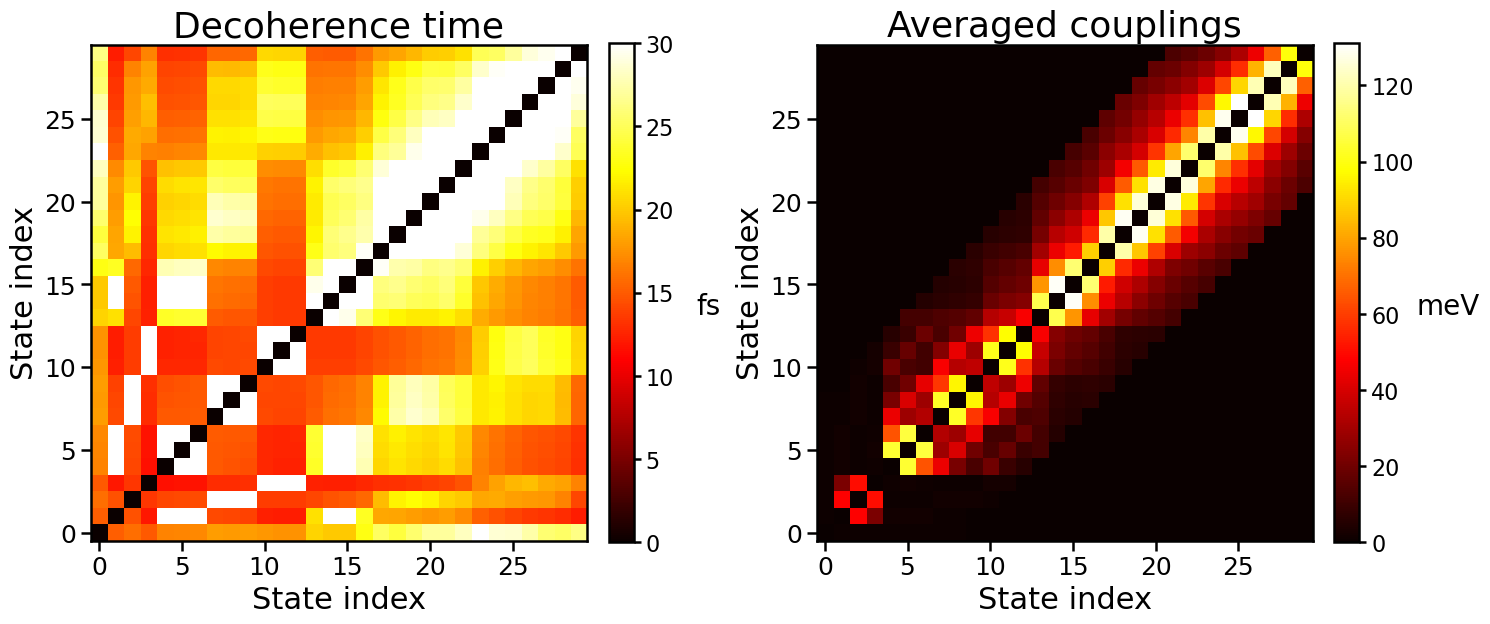

In [18]:
TITLE_SIZE   = 26   
LABEL_SIZE   = 22    
TICK_SIZE    = 18   
CBAR_LABEL   = 20   
CBAR_TICK    = 16   
TICK_WIDTH   = 1.8   
TICK_LENGTH  = 7     
SPINE_WIDTH  = 1.8  

def style_axis(ax, im, title, cbar_unit):
  
    ax.set_xlabel("State index", fontsize=LABEL_SIZE)
    ax.set_ylabel("State index", fontsize=LABEL_SIZE)
    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE,
                   width=TICK_WIDTH, length=TICK_LENGTH)
    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_WIDTH)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_unit, fontsize=CBAR_LABEL, rotation=0, labelpad=25)
    cbar.ax.tick_params(labelsize=CBAR_TICK, width=TICK_WIDTH, length=TICK_LENGTH - 2)
    cbar.outline.set_linewidth(SPINE_WIDTH)
    return cbar

avg_deco = np.loadtxt('decoherence_times.txt')

nacs = numpy_nac_adi
avg_coupling_meV = np.mean(np.abs(nacs), axis=0) * units.au2ev * 1000.0  # to meV
np.fill_diagonal(avg_coupling_meV, 0.0)

band = 8
idx = np.arange(NSTATES)
masked = np.where(np.abs(idx[:, None] - idx[None, :]) <= band,
                  avg_coupling_meV, 0.0)


fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# left：Decoherence time
im1 = axes[0].imshow(avg_deco, origin="lower", cmap="hot",
                     interpolation="nearest", aspect="equal",
                     vmin=0, vmax=30)
style_axis(axes[0], im1, "Decoherence time", "fs")

# Right：NAC
im2 = axes[1].imshow(masked, origin="lower", cmap="hot",
                     interpolation="nearest", aspect="equal")
style_axis(axes[1], im2, "Averaged couplings", "meV")

plt.tight_layout()
plt.show()

## NAC Distribution

The nonadiabatic coupling between the ground and first excited states, $|NAC(S_0,S_1)|$, was extracted from the imaginary part of the Step 3 `adamantane_results` over the selected trajectory interval from step `5900` to `8900`.

The coupling values were converted from atomic units to meV using `units.au2ev`. Their probability-density distribution was then calculated and normalized so that the total integrated area equals one.

The resulting NAC distribution was plotted on logarithmic scales to better visualize the low-probability region and the spread of coupling values.

Mode: 01 | number of pairs: 1
Number of samples: 3000
min, max (meV): 4.726120766198766e-05 6.539848565408346


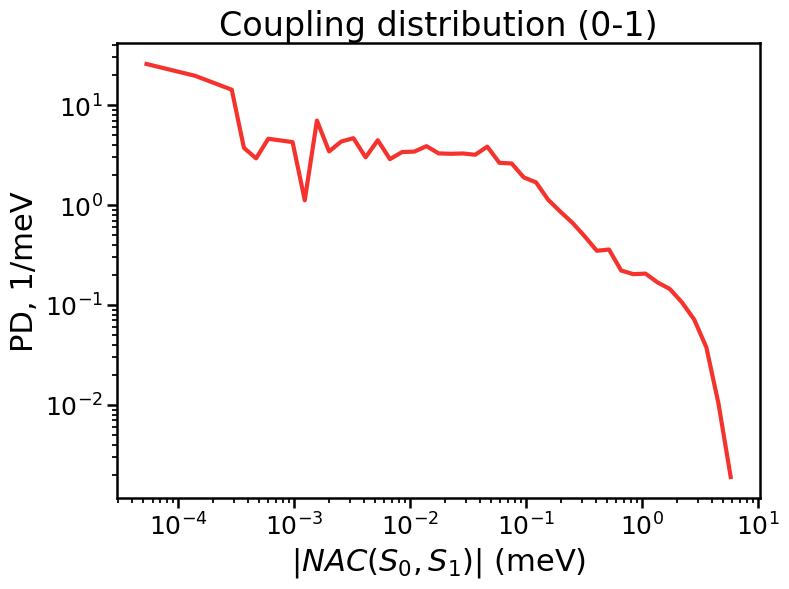

In [27]:
TITLE_SIZE  = 24
LABEL_SIZE  = 22
TICK_SIZE   = 18
TICK_WIDTH  = 1.8
TICK_LENGTH = 7
SPINE_WIDTH = 1.8
FIXED_COLOR = "#F6322D"   

# mode = "neighbor" : |NAC(S_i,S_i+1)|$ (meV)
# mode = "01"       : |NAC(S_0,S_1)|$ (meV)
mode = "01"

nacs = numpy_nac_adi   # shape: (nsteps, nstates, nstates)

if mode == "neighbor":
    i_idx = np.arange(NSTATES - 1)
    j_idx = i_idx + 1
    title = "Coupling distribution (neighbors)"
    xlabel = r"$|NAC(S_i,S_i+1)|$ (meV)"
elif mode == "01":
    i_idx = np.array([0])
    j_idx = np.array([1])
    title = "Coupling distribution (0-1)"
    xlabel = r"$|NAC(S_0,S_1)|$ (meV)"
else:
    raise ValueError("mode can be 'neighbor' or '01'")


all_couplings = np.abs(nacs[:, i_idx, j_idx]).ravel() * units.au2ev * 1000.0
all_couplings = all_couplings[all_couplings > 0]   # 

print("Mode:", mode, "| number of pairs:", len(i_idx))
print("Number of samples:", len(all_couplings))
print("min, max (meV):", all_couplings.min(), all_couplings.max())


bins = np.logspace(np.log10(all_couplings.min()),
                   np.log10(all_couplings.max()), 50)
hist, edges = np.histogram(all_couplings, bins=bins, density=True)
centers = np.sqrt(edges[:-1] * edges[1:])   
mask = hist > 0


fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(centers[mask], hist[mask], linewidth=3, color=FIXED_COLOR)
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(xlabel, fontsize=LABEL_SIZE)
ax.set_ylabel("PD, 1/meV", fontsize=LABEL_SIZE)
ax.set_title(title, fontsize=TITLE_SIZE)
ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE,
               width=TICK_WIDTH, length=TICK_LENGTH)
ax.tick_params(axis='both', which='minor',
               width=TICK_WIDTH * 0.7, length=TICK_LENGTH / 2)
for spine in ax.spines.values():
    spine.set_linewidth(SPINE_WIDTH)

plt.tight_layout()
plt.show()

## S$_1$–S$_0$ Energy-Gap Distribution

The diagonal energies of the ground and first excited states were extracted from the Step 3 `adamantane_results` files over the selected trajectory interval from step `5900` to `8900`.

The S$_1$–S$_0$ energy gap was converted from atomic units to electronvolts using `units.au2ev`. Its probability-density distribution was then evaluated with a bin width of `30` and normalized so that the total integrated area equals one.

The resulting distribution was plotted on a logarithmic scale, and the most probable energy gap was identified from the maximum of the probability density.

Mean gap  : 6.3018 eV
Std  dev  : 0.0673 eV
Min / Max : 6.0666 / 6.5165 eV


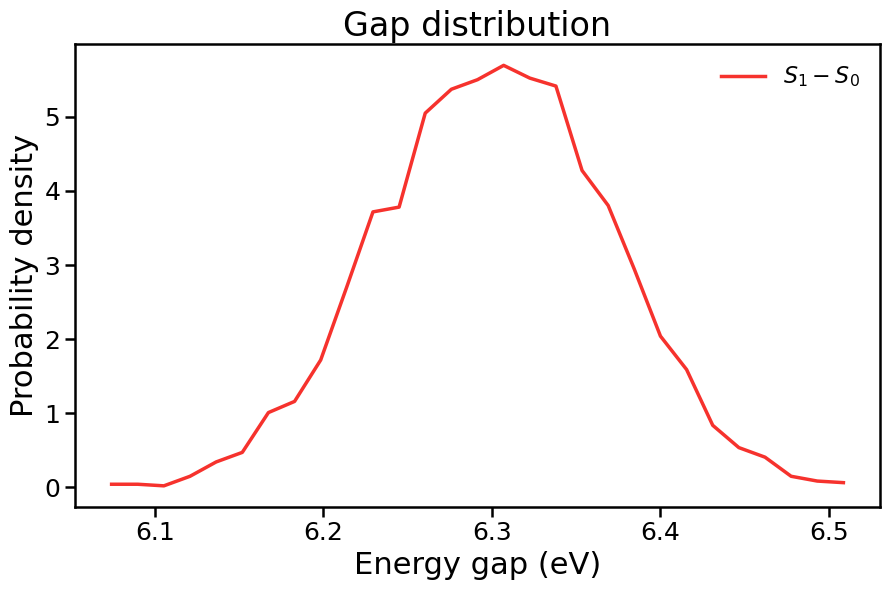

In [26]:
TITLE_SIZE  = 24
LABEL_SIZE  = 22
TICK_SIZE   = 18
LEGEND_SIZE = 16
TICK_WIDTH  = 1.8
TICK_LENGTH = 7
SPINE_WIDTH = 1.8
FIXED_COLOR = "#F6322D"   

gap_10 = (numpy_ham_adi[:, 1, 1] - numpy_ham_adi[:, 0, 0]) * units.au2ev

print(f"Mean gap  : {gap_10.mean():.4f} eV")
print(f"Std  dev  : {gap_10.std():.4f} eV")
print(f"Min / Max : {gap_10.min():.4f} / {gap_10.max():.4f} eV")

bins = np.linspace(gap_10.min(), gap_10.max(), 30)
hist, edges = np.histogram(gap_10, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(centers, hist, linewidth=2.5, color=FIXED_COLOR, label=r"$S_1-S_0$")

ax.set_xlabel("Energy gap (eV)", fontsize=LABEL_SIZE)
ax.set_ylabel("Probability density", fontsize=LABEL_SIZE)
ax.set_title("Gap distribution", fontsize=TITLE_SIZE)
# ax.set_xlim(0, 0.25)
ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE,
               width=TICK_WIDTH, length=TICK_LENGTH)
for spine in ax.spines.values():
    spine.set_linewidth(SPINE_WIDTH)

ax.legend(fontsize=LEGEND_SIZE, frameon=False)
plt.tight_layout()
plt.savefig("gap_S1_S0.png", dpi=300)
plt.show()

## Save NAC and Energy Gap Data for Multi-System Comparison

To compare the nonadiabatic couplings (NACs) and energy gaps of this system with other systems in the same figure, the raw time-series data are saved as `.npy` files. Each system is processed separately, and the saved files are later loaded together by a single plotting script.

### What is saved

| Quantity | Definition | Unit | File name (example) |
|---|---|---|---|
| S0–S1 coupling | $\lvert NAC_{01}(t) \rvert$ | meV | `nac01_sysA.npy` |
| Neighboring-state couplings | $\lvert NAC_{i,i+1}(t) \rvert$ for all $i$, flattened | meV | `nacnb_sysA.npy` |
| S1–S0 energy gap | $E_1(t) - E_0(t)$ | eV | `gap10_sysA.npy` |

- The NACs are taken from `nacs` with shape `(nsteps, nstates, nstates)` and converted from atomic units to meV.
- The energy gap is taken from the diagonal of the adiabatic Hamiltonian `numpy_ham_adi` and converted to eV.
- Absolute values are used for the NACs, since the sign of the coupling depends on the arbitrary phase of the wavefunctions.

### Why save raw samples

The raw samples are saved instead of histograms, so that all systems can be binned with **common bin edges** at plotting time. This ensures that the distributions are directly comparable. Zero values are kept in the files and are only removed when plotting on a log scale.

### Usage

1. Run the code below for each system.
2. Replace the suffix `sysA` with `sysB`, `sysC`, etc., for each new system.
3. Load all saved files with `np.load(...)` in the comparison plotting script.

In [28]:
# ----------------------------
# S0 - S1 coupling
# ----------------------------
nac_01 = np.abs(nacs[:, 0, 1]) * units.au2ev * 1000.0   # meV

# Save: change the file name for each system
np.save("nac01_sysA.npy", nac_01)
print("saved:", nac_01.shape, nac_01.dtype)

# ----------------------------
# Neighboring-state couplings (i, i+1)
# ----------------------------
i_idx = np.arange(NSTATES - 1)
nac_nb = np.abs(nacs[:, i_idx, i_idx + 1]).ravel() * units.au2ev * 1000.0   # meV

# Save: change the file name for each system
np.save("nacnb_sysA.npy", nac_nb)
print("saved:", nac_nb.shape, nac_nb.dtype)

# ----------------------------
# S1 - S0 energy gap
# ----------------------------
gap_10 = (numpy_ham_adi[:, 1, 1] - numpy_ham_adi[:, 0, 0]) * units.au2ev   # eV

# Save: change the file name for each system
np.save("gap10_sysA.npy", gap_10)
print("saved:", gap_10.shape, gap_10.dtype)

saved: (3000,) float64
saved: (87000,) float64
saved: (3000,) float64


## All-Structures NAC and Energy-Gap Distributions

This cell/script computes and visualizes the probability distributions of non-adiabatic couplings (NACs) and energy gaps for all four adamantane structures.

### Purpose

The primary goal is to compare how the degree of methylation affects the distribution of:
1.  **Non-Adiabatic Couplings (NACs):** Specifically, the magnitude of the coupling between the ground state (S₀) and the first excited state (S₁), denoted as $|NAC(S_0, S_1)|$.
2.  **Energy Gaps:** The energy difference between the S₀ and S₁ states.

### Methodology

- **Data Source:** The script reads the vibronic Hamiltonian (`hvib_adi_*.txt`) and Hamiltonian (`ham_adi_*.txt`) files for each structure.
- **Frame Selection:** It processes a specific range of trajectory frames (defined by `FIRST_FRAME` and `LAST_FRAME`), which can be adjusted to match different simulation windows.
- **NAC Extraction:** The magnitude of the NAC is extracted from the imaginary part of the vibronic Hamiltonian matrix element, $|Im[Hvib_{ij}]|$.
- **Energy Gap Extraction:** The energy gap is calculated from the real diagonal elements of the Hamiltonian matrix, $|E_i - E_j|$.
- **Unit Conversion:** All values are converted to standard physical units: NACs to **meV** and energy gaps to **eV**.
- **Distribution Calculation:** The `data_stat.cmat_distrib` function from the Libra library is used to compute normalized probability density (PD) distributions for the collected NAC and energy-gap values.
- **Visualization:** The final output is a two-panel figure:
    - **Left Panel:** Shows the NAC distribution for all structures on a logarithmic scale.
    - **Right Panel:** Shows the energy-gap distribution for all structures.

This analysis provides a statistical overview of the excited-state properties and their dependence on the molecular structure.

In [ ]:
#!/usr/bin/env python3

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from libra_py import units
from libra_py import data_stat
from liblibra_core import CMATRIX


# ============================================================
# Settings
# ============================================================

BASE_DIR = "/home/hamid/A"

SYSTEMS = {
    "step3_0/adamantane": "Adamantane",
    "step3_1/1methyl_adamantane": "1-methyl-adamantane",
    "step3_2/2methyl_adamantane": "2-methyl-adamantane",
    "step3_3/3methyl_adamantane": "3-methyl-adamantane",
}

OUT_DIR = os.path.join(
    BASE_DIR,
    "all_structures_distributions"
)

os.makedirs(OUT_DIR, exist_ok=True)


# ============================================================
# Frame range
# ============================================================
# Current calculation:
# 0 ... 3000 = 3001 frames
#
# To reproduce Qingxin's NAMD range, change:
# LAST_FRAME = 2499
#
# Then the code will use exactly 2500 frames:
# 0 ... 2499
# ============================================================

FIRST_FRAME = 0
LAST_FRAME = 3000


# ============================================================
# State pairs
# ============================================================

# NAC distribution:
# Ground state with the first three excited states:
#
# S0-S1
# S0-S2
# S0-S3

NAC_PAIRS = [
    (0, 1),

]


# Energy-gap distribution:
# Ground state and first excited state only:
#
# S0-S1

GAP_PAIR = (0, 1)


# ============================================================
# Plot ranges
# ============================================================

NAC_XMIN = 0.1
NAC_XMAX = 6.0

GAP_XMIN = 6.0
GAP_XMAX = 7.0


# ============================================================
# Histogram resolution
# ============================================================

NAC_DX = 0.1
GAP_DX = 0.01


# ============================================================
# Read Libra matrix
# ============================================================

def read_libra_matrix(filename):

    rows = []

    with open(filename, "r") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            row = []

            for token in line.split():

                token = token.strip("()")

                re_part, im_part = token.split(",")

                row.append(
                    complex(
                        float(re_part),
                        float(im_part)
                    )
                )

            rows.append(row)

    nrows = len(rows)
    ncols = len(rows[0])

    mat = CMATRIX(nrows, ncols)

    for i in range(nrows):

        for j in range(ncols):

            mat.set(
                i,
                j,
                rows[i][j]
            )

    return mat


# ============================================================
# Calculate distributions for one system
# ============================================================

def calculate_distributions(data_dir):

    hvib_files = sorted(
        glob.glob(
            os.path.join(
                data_dir,
                "hvib_adi_*.txt"
            )
        ),
        key=lambda x: int(
            os.path.basename(x)
            .split("_")[-1]
            .split(".")[0]
        )
    )

    ham_files = sorted(
        glob.glob(
            os.path.join(
                data_dir,
                "ham_adi_*.txt"
            )
        ),
        key=lambda x: int(
            os.path.basename(x)
            .split("_")[-1]
            .split(".")[0]
        )
    )

    print()
    print("=" * 70)
    print(data_dir)
    print("=" * 70)

    print(f"Total Hvib files = {len(hvib_files)}")
    print(f"Total Ham files  = {len(ham_files)}")

    if len(hvib_files) != len(ham_files):
        raise RuntimeError(
            "Hvib/Ham file counts are different!"
        )

    # --------------------------------------------------------
    # Select requested frame range
    # --------------------------------------------------------

    selected_hvib = []
    selected_ham = []

    for hvib_file, ham_file in zip(
        hvib_files,
        ham_files
    ):

        frame_hvib = int(
            os.path.basename(hvib_file)
            .split("_")[-1]
            .split(".")[0]
        )

        frame_ham = int(
            os.path.basename(ham_file)
            .split("_")[-1]
            .split(".")[0]
        )

        if frame_hvib != frame_ham:
            raise RuntimeError(
                f"Frame mismatch: "
                f"{frame_hvib} vs {frame_ham}"
            )

        if FIRST_FRAME <= frame_hvib <= LAST_FRAME:

            selected_hvib.append(hvib_file)
            selected_ham.append(ham_file)

    print(
        f"Using frames = "
        f"{FIRST_FRAME} ... {LAST_FRAME}"
    )

    print(
        f"Number of selected frames = "
        f"{len(selected_hvib)}"
    )

    if len(selected_hvib) == 0:
        raise RuntimeError(
            "No frames found in the requested range!"
        )

    # --------------------------------------------------------
    # Check first matrix
    # --------------------------------------------------------

    hvib0 = read_libra_matrix(
        selected_hvib[0]
    )

    ham0 = read_libra_matrix(
        selected_ham[0]
    )

    nstates = hvib0.num_of_rows

    print(
        f"Matrix size = "
        f"{hvib0.num_of_rows} x "
        f"{hvib0.num_of_cols}"
    )

    if nstates < 4:
        raise RuntimeError(
            "At least 4 electronic states are required "
            "for S0-S3 NACs."
        )

    # --------------------------------------------------------
    # Print state-pair information
    # --------------------------------------------------------

    print()
    print("NAC pairs:")
    for i, j in NAC_PAIRS:
        print(
            f"  S{i} - S{j}"
        )

    print()
    print(
        f"Energy-gap pair: "
        f"S{GAP_PAIR[0]} - S{GAP_PAIR[1]}"
    )

    # --------------------------------------------------------
    # Containers
    # --------------------------------------------------------

    nac = []
    gaps = []

    # --------------------------------------------------------
    # Process selected frames
    # --------------------------------------------------------

    for iframe, (
        hvib_file,
        ham_file
    ) in enumerate(
        zip(
            selected_hvib,
            selected_ham
        )
    ):

        hvib = read_libra_matrix(
            hvib_file
        )

        ham = read_libra_matrix(
            ham_file
        )

        # ====================================================
        # NAC
        # ====================================================
        #
        # Only:
        # S0-S1
        # S0-S2
        # S0-S3
        #
        # The reverse pairs are NOT counted separately.
        # ====================================================

        for i, j in NAC_PAIRS:

            nac_ij = abs(
                hvib.get(i, j).imag
            )

            nac_mev = (
                nac_ij
                * 1000.0
                * units.au2ev
            )

            x = CMATRIX(1, 1)

            x.set(
                0,
                0,
                nac_mev
            )

            nac.append(x)

        # ====================================================
        # Energy gap
        # ====================================================
        #
        # Only S0-S1
        # ====================================================

        i, j = GAP_PAIR

        energy_i = ham.get(
            i,
            i
        ).real

        energy_j = ham.get(
            j,
            j
        ).real

        gap_au = abs(
            energy_i - energy_j
        )

        gap_ev = (
            gap_au
            * units.au2ev
        )

        x = CMATRIX(1, 1)

        x.set(
            0,
            0,
            gap_ev
        )

        gaps.append(x)

        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (iframe + 1) % 500 == 0:

            print(
                f"  processed "
                f"{iframe + 1}/"
                f"{len(selected_hvib)}"
            )

    # ========================================================
    # Number of data points
    # ========================================================

    print()
    print(
        f"NAC data points = "
        f"{len(nac)}"
    )

    print(
        f"Expected NAC points = "
        f"{len(selected_hvib)} × "
        f"{len(NAC_PAIRS)} = "
        f"{len(selected_hvib) * len(NAC_PAIRS)}"
    )

    print(
        f"Energy-gap data points = "
        f"{len(gaps)}"
    )

    print(
        f"Expected gap points = "
        f"{len(selected_hvib)} × 1 = "
        f"{len(selected_hvib)}"
    )

    # ========================================================
    # Libra distributions
    # ========================================================

    nac_bins, nac_density, _ = data_stat.cmat_distrib(
        nac,
        0,
        0,
        0,
        0.0,
        6.0,
        NAC_DX
    )

    gap_bins, gap_density, _ = data_stat.cmat_distrib(
        gaps,
        0,
        0,
        0,
        0.0,
        8.0,
        GAP_DX
    )

    # ========================================================
    # Convert to numpy arrays
    # ========================================================

    nac_bins = np.asarray(
        nac_bins,
        dtype=float
    )

    nac_density = np.asarray(
        nac_density,
        dtype=float
    )

    gap_bins = np.asarray(
        gap_bins,
        dtype=float
    )

    gap_density = np.asarray(
        gap_density,
        dtype=float
    )

    return (
        nac_bins,
        nac_density,
        gap_bins,
        gap_density
    )


# ============================================================
# Calculate all four systems
# ============================================================

results = {}

for relative_dir, label in SYSTEMS.items():

    data_dir = os.path.join(
        BASE_DIR,
        relative_dir
    )

    results[label] = calculate_distributions(
        data_dir
    )


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.0, 3.0),
    dpi=300
)

ax_nac = axes[0]
ax_gap = axes[1]


# ============================================================
# NAC distribution
# ============================================================

for label, (
    nac_bins,
    nac_density,
    gap_bins,
    gap_density
) in results.items():

    mask = (
        (nac_bins >= NAC_XMIN)
        & (nac_bins <= NAC_XMAX)
        & (nac_density > 0)
    )

    ax_nac.plot(
        nac_bins[mask],
        nac_density[mask],
        linewidth=1.3,
        label=label
    )


ax_nac.set_xlim(
    NAC_XMIN,
    7#NAC_XMAX
)

ax_nac.set_xscale("log")
ax_nac.set_yscale("log")

ax_nac.set_ylim(
    1e-3,
    4
)

ax_nac.set_xlabel(
    "|NAC| (meV)"
)

ax_nac.set_ylabel(
    "PD (1/meV)"
)

ax_nac.set_title(
    "NAC distribution"
)

ax_nac.legend(
    fontsize=6
)


# ============================================================
# Energy-gap distribution
# ============================================================

for label, (
    nac_bins,
    nac_density,
    gap_bins,
    gap_density
) in results.items():

    mask = (
        (gap_bins >= GAP_XMIN)
        & (gap_bins <= GAP_XMAX)
        & (gap_density > 0)
    )

    ax_gap.plot(
        gap_bins[mask],
        gap_density[mask],
        linewidth=1.3,
        label=label
    )


ax_gap.set_xlim(
    GAP_XMIN,
    6.8#GAP_XMAX
)

ax_gap.set_yscale("log")

ax_gap.set_ylim(
    1e-2,
    7.0
)

ax_gap.set_xlabel(
    "Energy gap (eV)"
)

ax_gap.set_ylabel(
    "PD (1/eV)"
)

ax_gap.set_title(
    "Energy-gap distribution"
)


# ============================================================
# Layout
# ============================================================

plt.tight_layout()


# ============================================================
# Save
# ============================================================

outfile = os.path.join(
    OUT_DIR,
    "all_structures_NAC_energy_gap_S0_pairs.png"
)

plt.savefig(
    outfile,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Final information
# ============================================================

print()
print("=" * 70)
print("DONE")
print("=" * 70)

print()
print("Frame range:")
print(
    f"  {FIRST_FRAME} ... {LAST_FRAME}"
)

print(
    f"  Total frames: "
    f"{LAST_FRAME - FIRST_FRAME + 1}"
)

print()
print("NAC pairs:")
for i, j in NAC_PAIRS:
    print(
        f"  S{i} - S{j}"
    )

print()
print(
    f"Energy gap: "
    f"S{GAP_PAIR[0]} - S{GAP_PAIR[1]}"
)

print()
print("Saved:")
print(outfile)